# Task 3: Simple Vectorized Convolution via im2col

Transform spatial image sliding windows into a single fast 2D matrix dot product.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

### 1. Input Image and Convolution Kernel

In [2]:
# 4x4 Input Image
image = np.array([
    [1, 2, 0, 1],
    [0, 1, 3, 2],
    [2, 3, 1, 0],
    [1, 0, 2, 1]
], dtype=float)

# 2x2 Filter Kernel
kernel = np.array([
    [1, 0],
    [0, -1]
], dtype=float)

### 2. Convert Image Windows to Matrix Columns (`im2col`)

In [3]:
# Extract all 2x2 sliding windows into columns
columns = []
for r in range(3):       # Row index
    for c in range(3):   # Column index
        window = image[r:r+2, c:c+2].flatten()
        columns.append(window)

im2col_matrix = np.array(columns).T  # Shape: (4, 9)
print('Image Windows Reshaped Matrix (im2col):\n', im2col_matrix)

Image Windows Reshaped Matrix (im2col):
 [[1. 2. 0. 0. 1. 3. 2. 3. 1.]
 [2. 0. 1. 1. 3. 2. 3. 1. 0.]
 [0. 1. 3. 2. 3. 1. 1. 0. 2.]
 [1. 3. 2. 3. 1. 0. 0. 2. 1.]]


### 3. Compute Convolution as Single Matrix Multiplication

In [4]:
kernel_vector = kernel.flatten()                # Flatten kernel to shape (4,)
conv_output = np.dot(kernel_vector, im2col_matrix) # Dot product!
output_grid = conv_output.reshape(3, 3)          # Reshape back to 3x3 grid

print('\nConvolution Output Grid (3x3):\n', output_grid)


Convolution Output Grid (3x3):
 [[ 0. -1. -2.]
 [-3.  0.  3.]
 [ 2.  1.  0.]]


### 4. Display Input vs Output Grid

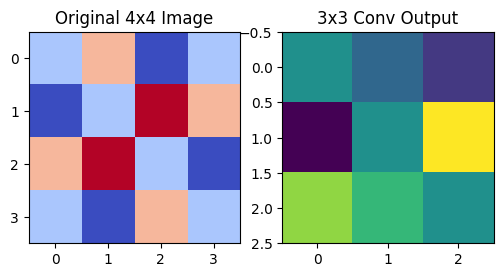

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(6, 3))
ax[0].imshow(image, cmap='coolwarm')
ax[0].set_title('Original 4x4 Image')
ax[1].imshow(output_grid, cmap='viridis')
ax[1].set_title('3x3 Conv Output')
plt.show()